In [6]:
import pandas as pd

df = pd.read_csv('../data/Funnel_Analysis_Data.csv')

df.head()

,User ID,Session ID,Event Time,Event,Device,Region,Channel,Product Category,Revenue,Bonus Flag
0,USR-00001,SES-00001,2026-01-07 23:46:20.358501,Browse,Tablet,South,Organic,Electronics,0.0,Yes
1,USR-00001,SES-00001,2026-01-07 23:49:20.358501,Add to Cart,Tablet,South,Organic,Electronics,0.0,Yes
2,USR-00001,SES-00001,2026-01-07 23:51:20.358501,Checkout,Tablet,South,Organic,Electronics,0.0,Yes
3,USR-00002,SES-00002,2026-01-04 21:06:42.296010,Browse,Desktop,East,Email,Sports,0.0,Yes
4,USR-00002,SES-00002,2026-01-04 21:10:42.296010,Add to Cart,Desktop,East,Email,Sports,0.0,Yes


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21409 entries, 0 to 21408
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User ID           21409 non-null  str    
 1   Session ID        21409 non-null  str    
 2   Event Time        21409 non-null  str    
 3   Event             21409 non-null  str    
 4   Device            21409 non-null  str    
 5   Region            21409 non-null  str    
 6   Channel           21409 non-null  str    
 7   Product Category  21409 non-null  str    
 8   Revenue           21409 non-null  float64
 9   Bonus Flag        21409 non-null  str    
dtypes: float64(1), str(9)
memory usage: 1.6 MB


In [8]:
df.shape

(21409, 10)

In [9]:
df.isnull().sum()

User ID             0
Session ID          0
Event Time          0
Event               0
Device              0
Region              0
Channel             0
Product Category    0
Revenue             0
Bonus Flag          0
dtype: int64

In [10]:
df.columns

Index(['User ID', 'Session ID', 'Event Time', 'Event', 'Device', 'Region',
       'Channel', 'Product Category', 'Revenue', 'Bonus Flag'],
      dtype='str')

In [11]:
df['Event'].unique()

<StringArray>
['Browse', 'Add to Cart', 'Checkout', 'Purchase']
Length: 4, dtype: str

In [12]:
df['Device'].unique()

<StringArray>
['Tablet', 'Desktop', 'Mobile']
Length: 3, dtype: str

In [13]:
df['Channel'].unique()

<StringArray>
['Organic', 'Email', 'Google Ads', 'Social Media']
Length: 4, dtype: str

In [14]:
df['Region'].unique()

<StringArray>
['South', 'East', 'West', 'North']
Length: 4, dtype: str

In [15]:
df['Product Category'].unique()

<StringArray>
['Electronics', 'Sports', 'Fashion', 'Beauty', 'Home']
Length: 5, dtype: str

In [16]:
df.groupby('Event')['User ID'].nunique()

Event
Add to Cart     6949
Browse         10000
Checkout        3456
Purchase        1004
Name: User ID, dtype: int64

In [17]:
funnel = df.groupby('Event')['User ID'].nunique().reset_index()

funnel.columns = ['Event', 'Users']

funnel

,Event,Users
0,Add to Cart,6949
1,Browse,10000
2,Checkout,3456
3,Purchase,1004


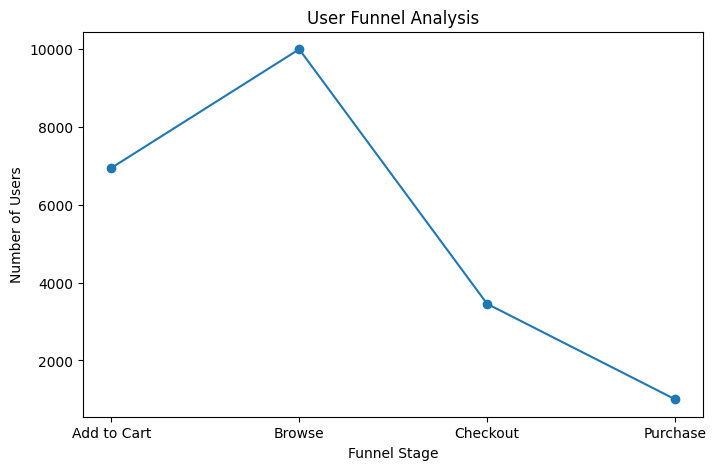

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(funnel['Event'], funnel['Users'], marker='o')

plt.title('User Funnel Analysis')

plt.xlabel('Funnel Stage')

plt.ylabel('Number of Users')

plt.show()

In [19]:
browse_users = funnel[funnel['Event']=='Browse']['Users'].values[0]

purchase_users = funnel[funnel['Event']=='Purchase']['Users'].values[0]

conversion_rate = (purchase_users / browse_users) * 100

print(f"Conversion Rate: {conversion_rate:.2f}%")

Conversion Rate: 10.04%


In [20]:
funnel['Drop_off'] = funnel['Users'].shift(1) - funnel['Users']

funnel

,Event,Users,Drop_off
0,Add to Cart,6949,NaN
1,Browse,10000,-3051.0
2,Checkout,3456,6544.0
3,Purchase,1004,2452.0
